# Import package

In [1]:
#supposedly these were already done from command line
#git clone https://github.com/hshadman/pyheteromap.git
#cd pyheteromap
#python -m pip install -e .

In [2]:
import pyheteromap
from pyheteromap import PyHeteroMap
import os

# Initialize

## Examples are from the human IDR-ome dataset (https://www.nature.com/articles/s41586-023-07004-5)

In [3]:
# example 1
h1 = PyHeteroMap('Q8WV44_43_186',traj_file_dir='test_data/traj1.xtc',
                 prmtop_file_dir='test_data/top1.pdb') # 'Q8WV44_43_186' is the seq_name for the IDR in traj1, top1. 
# example 2
h2 = PyHeteroMap('Q9UIF8_1259_1347',traj_file_dir='test_data/traj2.xtc',
                 prmtop_file_dir='test_data/top2.pdb') # 'Q9UIF8_1259_1347' is the seq_name for the IDR in traj2, top2. 

Note: The first 10 frames in the trajectory were skipped.

The code as written is for CG simulations (one "bead" per amino acid residue).

If all-atom, users may want CA atoms instead:

self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]

Modify accordingly in set_trajectory and inside the subchain loop in initialize_30mer_subchain.
Note: The first 10 frames in the trajectory were skipped.

The code as written is for CG simulations (one "bead" per amino acid residue).

If all-atom, users may want CA atoms instead:

self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]

Modify accordingly in set_trajectory and inside the subchain loop in initialize_30mer_subchain.


# Generate Global (whole chain) Conformational Ensemble

Data loading...

Data loaded. Visualizing now, this could take some time.
Loaded reference GW chain from: /project/hshadman/hshadman/polym_sep/github_subchain_code/src/pyheteromap/reference_GW_chainlength_100.csv

500000 GW snapshots processed
1000000 GW snapshots processed


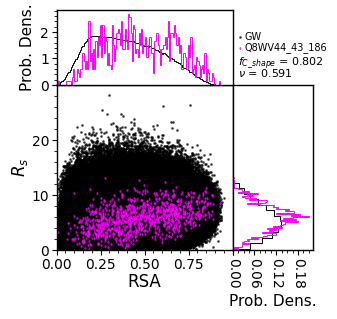

In [4]:
# example 1
h1.mod_RSA_Rs_compute_3dplot_from_seq_name()

Data loading...

Data loaded. Visualizing now, this could take some time.
Loaded reference GW chain from: /project/hshadman/hshadman/polym_sep/github_subchain_code/src/pyheteromap/reference_GW_chainlength_100.csv

500000 GW snapshots processed
1000000 GW snapshots processed


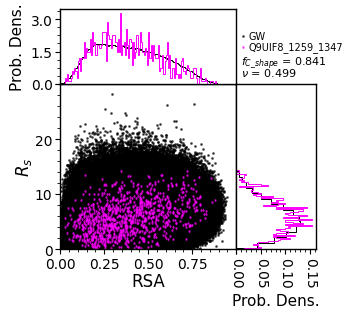

In [5]:
# example 2
h2.mod_RSA_Rs_compute_3dplot_from_seq_name()

# Generate Subchain Plots

## Important: Subchain data needs to be initialized before generating subchain plots.

In [6]:
# example 1

# FASTA_CSV = path to a csv file connecting seq_name to fasta sequence (provided)
FASTA_CSV = os.path.join(os.path.dirname(pyheteromap.__file__), "Tesei_2024_IDR-ome_fasta_sequences.csv") 

h1.initialize_30mer_subchain(fasta_source = FASTA_CSV) # the subchain data is stored in h1._subchain_df


NOTE: Subchain calculation might take longer for longer peptides/IDRs.

NOTE: If peptide length is smaller than 5 residues, nu cannot be computed.

If the fasta sequences in the csv file are arranged differently,modify this section of the code to properly read in fasta_sequence.

If <= 60 residues, the moving window is ~1/3rd (by default) of the number of residues.
If > 60 residues, the moving window is 30 residues.

AFRC calculates in Angstrom units.
Since MDTraj calculations are in nm units, a conversion variable "scale" is applied.
If needed, modify the "scale" variable in initialize_30mer_subchain.

Subchain data generated.



,fasta_sequence,start_res_zeroindex,end_res_zeroindex,full_protein_fasta,full_protein_rgyr,full_protein_nu_recompute,full_protein_nu_recompute_err,full_protein_ratio,full_protein_RSA,full_protein_rg_rg_theta_mean,seq_name,Rg/nm,nu_recompute,nu_recompute_err,ete,inst_ratio,RSA,AFRC_mean_rg_theta,rg_rg_theta_mean
0,CVTQLWGGEDEEDRDELDREEEEEDGEEEE,0,29,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.488824,0.668842,0.009125,4.051217,7.404308,0.365725,13.605010,1.094320
1,CVTQLWGGEDEEDRDELDREEEEEDGEEEE,0,29,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,2.042888,0.668842,0.009125,6.154834,9.077024,0.693428,13.605010,1.501571
2,CVTQLWGGEDEEDRDELDREEEEEDGEEEE,0,29,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.880031,0.668842,0.009125,3.905740,4.315954,0.586161,13.605010,1.381866
3,CVTQLWGGEDEEDRDELDREEEEEDGEEEE,0,29,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.923909,0.668842,0.009125,4.956666,6.637591,0.711328,13.605010,1.414118
4,CVTQLWGGEDEEDRDELDREEEEEDGEEEE,0,29,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.360955,0.668842,0.009125,3.806114,7.821251,0.357842,13.605010,1.000334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,LEEVEEEDLDPVTPLPPPPAPRRCFTCPQC,114,143,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.351749,0.480951,0.007255,1.962293,2.107345,0.291458,13.683353,0.987878
996,LEEVEEEDLDPVTPLPPPPAPRRCFTCPQC,114,143,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.323829,0.480951,0.007255,1.785342,1.818774,0.406853,13.683353,0.967474
997,LEEVEEEDLDPVTPLPPPPAPRRCFTCPQC,114,143,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.647278,0.480951,0.007255,4.332218,6.916506,0.512452,13.683353,1.203856
998,LEEVEEEDLDPVTPLPPPPAPRRCFTCPQC,114,143,CVTQLWGGEDEEDRDELDREEEEEDGEEEEVEAVGAGAGWDTPMRD...,4.738058,0.591165,0.004419,5.804931,0.474561,1.58381,Q8WV44_43_186,1.019651,0.480951,0.007255,2.085333,4.182609,0.158655,13.683353,0.745177


## visualize subchain information

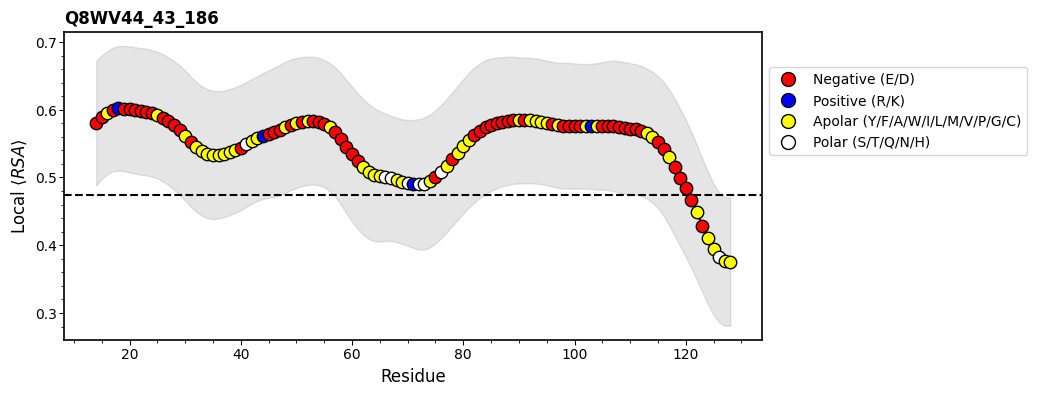

In [7]:
# example 1
# dotted line shows global
h1.plot_subchain_RSA(9,4) # provide figure width, figure height

This is computing a ⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ plot.
⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ is also referred to as ⟨α⟩ in the associated paper.
⟨R₍g₎ᶿ⟩ was computed directly from sequence using an Analytical Flory Random Coil (AFRC) reference, Alston et al. 2023


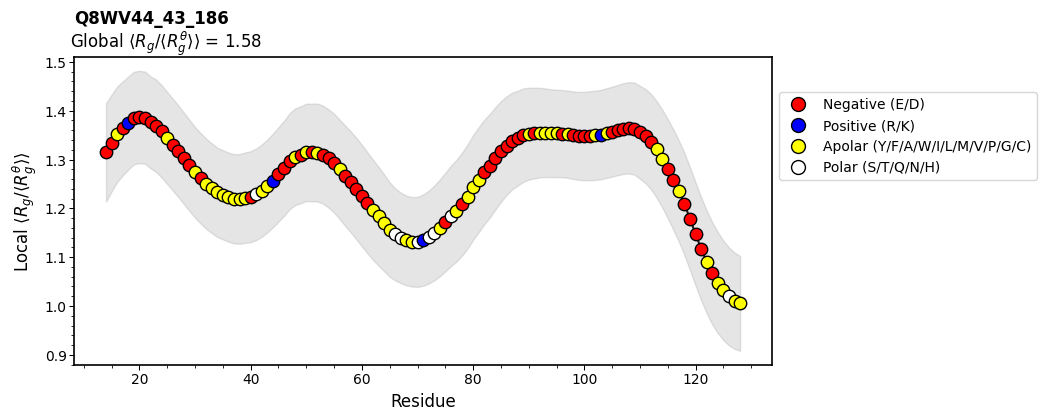

In [8]:
# example 1

h1.plot_subchain_Rg_over_Rgtheta(9,4) # provide figure width, figure height

nu formula is from Tesei et al. 2024


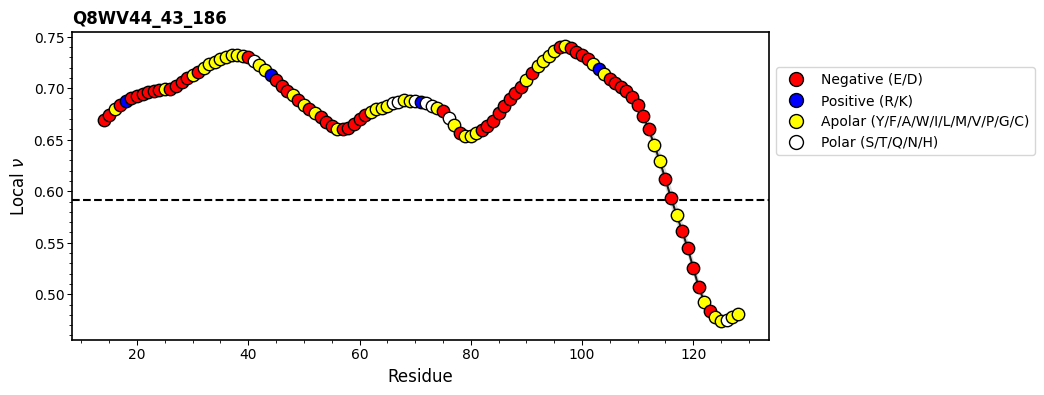

In [9]:
# example 1
# dotted line shows global
# uses nu formula from Tesei et al. 2024
h1.plot_subchain_nu(9,4) # provide figure width, figure height

# Simulate a GW chain

In [10]:
h1.regenerate_GW_chain(100,1000) # a GW chain of 100 monomers, 1000 snapshots in simulation

# To save this new GW chain, do h1.export_gw_csv('./GW_regenerated.csv')

# now this new chain replaces the default chain data in h1. To recover that default GW data, h1.reinitialize_gw_reference()

# GW chain data stored in h1.gw_df

# each row in h1.gw_df is a snapshot of the GW simulation

chain_length=100, Nosnaps=1000, interval= 1
New GW chain generated and stored in self.gw_df.
To save, call export_gw_csv('GW_regenerated.csv').


# Generate (RSA, _R<sub>s</sub>_) Scatter Plots from a csv file containing RSA and _R<sub>s</sub>_ data
# NO trajectory needed

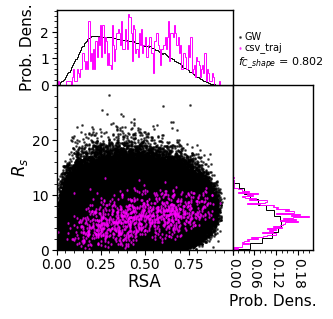

In [11]:
%%capture --no-display output

# random example - no trajectory but a csv file containing Rs and RSA are available.
h3 = PyHeteroMap('csv_traj',traj_file_dir=None,
                 prmtop_file_dir=None) 

# must provide a label for the protein data
h3.mod_RSA_Rs_compute_3dplot_from_csv('./test_data/test_idr.csv', label = 'csv_traj')